# Batch Predictions with Prefect

This notebook shows how the registered MLflow model is reused in a batch workflow. Instead of retraining, we load the model from MLflow and score a whole Parquet file with the Prefect flow used by the project.

Before you run it, finish [02-train-ml-model.ipynb](02-train-ml-model.ipynb) so MLflow already has at least one registered model version to resolve.


## Workflow

```mermaid
flowchart LR
    A["Batch input<br>Parquet"] --> B["Prefect<br>flow"]
    B --> C["Resolve latest model<br>from MLflow"]
    C --> D["Score every<br>ride record"]
    D --> E["Write prediction<br>Parquet"]
```


## Run One Local Batch Flow

The flow reads the input Parquet file, resolves the latest registered model in MLflow, and writes a prediction Parquet file to the local `data/predictions/` directory.

In [1]:
from pathlib import Path

import pandas as pd

from src.batch.flow import score_batch_flow
from src.common.config import get_settings

settings = get_settings()
output_path = Path("data/predictions/notebook_batch_predictions.parquet")
settings

ProjectSettings(mlflow_tracking_uri='http://127.0.0.1:5001', prefect_api_url='http://127.0.0.1:4200/api', experiment_name='green-taxi-duration', registered_model_name='green-taxi-duration', model_uri=None, model_alias=None, model_stage=None, model_version=None, run_id=None, model_artifact_path='model', train_data_uri='https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet', batch_input_uri='https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet', batch_output_dir=PosixPath('/Users/youssef/projects/bootcamp/mle-batch-and-stream-predictions/data/predictions'), artifacts_dir=PosixPath('/Users/youssef/projects/bootcamp/mle-batch-and-stream-predictions/storage/mlartifacts'))

In [2]:
result_path = score_batch_flow(
    input_uri=settings.batch_input_uri,
    output_path=str(output_path),
)
result_path

16:25:39.260 | INFO    | Flow run 'hidden-swallow' - Beginning flow run 'hidden-swallow' for flow 'score-green-taxi-batch'

16:25:39.267 | INFO    | Flow run 'hidden-swallow' - View at http://127.0.0.1:4200/runs/flow-run/c867d2d3-e773-4c8c-827a-ce686aa2e4b6

16:25:39.281 | INFO    | Task run 'score_dataframe-737' - Reading input from https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet

16:25:40.069 | INFO    | Task run 'score_dataframe-737' - Loading model from models:/green-taxi-duration/2

16:25:47.113 | INFO    | Task run 'score_dataframe-737' - Saved predictions to data/predictions/notebook_batch_predictions.parquet

16:25:47.116 | INFO    | Task run 'score_dataframe-737' - Finished in state Completed()

16:25:47.378 | INFO    | Flow run 'hidden-swallow' - Finished in state Completed()

'data/predictions/notebook_batch_predictions.parquet'

In [3]:
predictions = pd.read_parquet(result_path)
predictions.head()

,ride_id,lpep_pickup_datetime,PULocationID,DOLocationID,trip_distance,predicted_duration,model_reference,actual_duration,diff
0,c26fce77-d87d-4cb1-a28b-607a89e06d3f,2025-02-01 00:12:15,166,41,0.65,6.341813,models:/green-taxi-duration/2,3.550000,-2.791813
1,914396c0-8c5e-45de-81d9-a94a6fb12e2d,2025-01-31 23:57:05,255,161,6.57,26.512416,models:/green-taxi-duration/2,27.316667,0.804251
2,f73a18ae-16a7-4569-b194-7a5104ba15b0,2025-02-01 00:24:26,75,182,8.36,23.125005,models:/green-taxi-duration/2,25.466667,2.341661
3,0a38976c-f349-4302-ae31-8a8f6fff7775,2025-02-01 00:17:15,97,209,2.40,14.931247,models:/green-taxi-duration/2,8.683333,-6.247913
4,0e53a11f-f484-40ed-ad2c-632e3791f09a,2025-02-01 00:17:36,7,223,1.31,9.186330,models:/green-taxi-duration/2,9.000000,-0.186330


## Interpret the Batch Output

Because this sample input still contains the observed trip duration, the output file includes both actual and predicted values. That gives us a quick way to check whether the batch run looks reasonable.

In [4]:
summary = pd.DataFrame(
    {
        "rows": [len(predictions)],
        "mean_actual_duration": [predictions["actual_duration"].mean()],
        "mean_predicted_duration": [predictions["predicted_duration"].mean()],
        "mean_absolute_error": [
            (predictions["actual_duration"] - predictions["predicted_duration"])
            .abs()
            .mean()
        ],
    }
)
summary

,rows,mean_actual_duration,mean_predicted_duration,mean_absolute_error
0,42588,13.68185,13.396082,3.260522


## Add One Helpful Comparison

Averages can hide a few large misses. The next cell surfaces the biggest absolute errors so you can inspect whether those rows look unusual.

In [5]:
largest_errors = predictions.assign(
    absolute_error=(
        predictions["actual_duration"] - predictions["predicted_duration"]
    ).abs()
).sort_values("absolute_error", ascending=False)

largest_errors[
    [
        "ride_id",
        "PULocationID",
        "DOLocationID",
        "trip_distance",
        "actual_duration",
        "predicted_duration",
        "absolute_error",
    ]
].head(10)

,ride_id,PULocationID,DOLocationID,trip_distance,actual_duration,predicted_duration,absolute_error
41956,6050cfea-4174-4659-990a-cfaf8b258d4d,65,177,44.62,28.000000,133.572755,105.572755
42269,fc5fd893-1ea3-476a-ba34-5241d4dcef2f,23,265,43.15,59.566667,117.976221,58.409554
41949,4ff7dfd1-f4dc-450e-9e96-5fa036207d04,42,132,2.85,43.000000,-14.345008,57.345008
41763,76fcbc17-524f-4f35-8372-d37c285ac7ec,189,17,24.40,13.000000,69.487009,56.487009
41922,02f850fd-eb3a-451a-8468-1a5e9bb4d738,171,92,11.81,9.000000,64.813919,55.813919
38229,725230f3-cde2-491d-8e4f-613c554d016c,66,132,27.26,6.666667,62.178398,55.511731
42575,6f04f74d-d2a3-445b-807c-590bd1c0be09,42,42,0.97,59.833333,5.906670,53.926663
42485,486694d5-23d0-4abd-be5e-92eb404866ca,75,74,0.96,59.350000,5.505779,53.844221
42243,d4f9fe40-d04b-4081-a3d4-47dc8a39abc3,74,41,0.69,59.833333,6.268278,53.565056
41072,647195e8-5d1d-4500-bf05-ee86b1c65c34,189,1,35.16,44.000000,97.313352,53.313352


## Visual Check: Actual vs Predicted Duration

A quick scatter plot gives a better intuition than a summary statistic alone. Points close to the diagonal line indicate trips where the batch prediction was close to the observed duration.

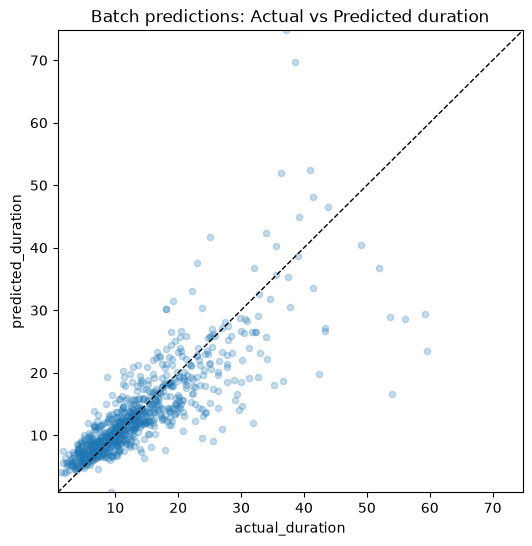

In [6]:
import matplotlib.pyplot as plt

sample_for_plot = predictions.sample(min(len(predictions), 800), random_state=42)
ax = sample_for_plot.plot.scatter(
    x="actual_duration",
    y="predicted_duration",
    alpha=0.25,
    figsize=(6, 6),
    title="Batch predictions: Actual vs Predicted duration",
)
limits = [
    min(
        sample_for_plot["actual_duration"].min(),
        sample_for_plot["predicted_duration"].min(),
    ),
    max(
        sample_for_plot["actual_duration"].max(),
        sample_for_plot["predicted_duration"].max(),
    ),
]
ax.plot(limits, limits, linestyle="--", color="black", linewidth=1)
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

## Schedule the Same Flow

The notebook runs the flow once. To keep it on a schedule, use the project helper below in a terminal:

```bash
uv run python -m src.batch.serve
```

That command starts a Prefect deployment using the cron expression from `.env`. It keeps running so Prefect can poll for scheduled runs; press `Ctrl + C` when you want to stop serving the deployment. If it fails, confirm that the local Prefect server is running and that `PREFECT_API_URL` still matches your local stack.
